# 02 — GDELT Preprocessing

This notebook preprocesses the raw GDELT country-week aggregation into clean media variables ready for the extended model.

| | |
|---|---|
| Countries | Mali, Niger, Nigeria, Burkina Faso, Ghana |
| Time frame | 2015-01-01 to 2023-12-31 |
| Unit of analysis | Country-week |
| Output | `processed/gdelt_country_week_processed.csv` |

---

## Pipeline

1. Load raw GDELT CSV (read entirely as strings to avoid mis-parsing)
2. Fix malformed numeric columns (see note below)
3. Validate numeric ranges
4. Parse dates and map 2-letter country codes to full names
5. Filter to target countries and date range
6. Snap week dates to Monday for alignment with ACLED
7. Build a complete country-week skeleton
8. Handle missing sentiment values
9. Add lagged media variables
10. Diagnostics and export

---

## Data quality note: AVG_TONE corruption

The raw GDELT export contains `AVG_TONE` values where the decimal point has been shifted one place to the left. For example, a true value of `-18.61` is stored as `-1.861...`. This appears to be a BigQuery export artefact where high-precision floats are serialised with too many decimal places, making them look like they have been divided by 10. The fix detects this by checking whether an `AVG_TONE` value falls in the range (-10, +10) with more than 6 decimal digits — values that are genuinely in that range are not this precise — and multiplies by 10 to recover the true value.

`AVG_GOLDSTEIN` has a different issue: some values have extra dots used as thousand separators within the decimal part (e.g. `-4.256.812365`). These are fixed by keeping only the first dot as the decimal separator.

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
# Paths relative to repo root
REPO_ROOT = Path().resolve().parent  # one level up from notebooks/

RAW_DIR   = REPO_ROOT / "raw_data"
PROC_DIR  = REPO_ROOT / "processed"

RAW_FILE = RAW_DIR / "GDELT_media_data.csv"
PROC_DIR.mkdir(parents=True, exist_ok=True)

# ── Country code map ────────────────────────────────────────────────────────────
# GDELT uses 2-letter FIPS codes, not ISO-2 in all cases.
# Burkina Faso uses UV (old FIPS) rather than BF (ISO-2) in many GDELT exports.
COUNTRY_CODE_MAP = {
    "ML": "Mali",
    "NI": "Niger",       # FIPS code for Niger
    "NE": "Niger",       # ISO-2 fallback
    "NG": "Nigeria",
    "UV": "Burkina Faso",  # FIPS code
    "BF": "Burkina Faso",  # ISO-2 fallback
    "GH": "Ghana",
}

TARGET_COUNTRIES = ["Mali", "Niger", "Nigeria", "Burkina Faso", "Ghana"]
START_DATE       = "2015-01-01"
END_DATE         = "2023-12-31"

print(f"Raw file: {RAW_FILE}")
print(f"File exists: {RAW_FILE.exists()}")

Raw file: C:\Users\faiza\Documents\Uni\Year 3\Thesis\Data Preprocessing\raw_data\bquxjob_3f540b25_19cd771474f.csv
File exists: True


## 1. Load Raw GDELT Data

The file is loaded with `dtype=str` so that all values come in as raw strings. This prevents pandas from silently misinterpreting the corrupted float values and allows us to apply the targeted fix before conversion.

In [2]:
df_raw = pd.read_csv(
    RAW_FILE,
    sep=",",
    encoding="utf-8",
    dtype=str,          # read everything as string — fixes applied manually below
    low_memory=False,
)

df_raw.columns = df_raw.columns.str.strip().str.upper()

print(f"Raw shape: {df_raw.shape}")
print("Columns:", df_raw.columns.tolist())
print("\nRaw dtypes:")
print(df_raw.dtypes)

Raw shape: (2346, 9)
Columns: ['COUNTRY', 'WEEK_START', 'EVENTS', 'TOTAL_MENTIONS', 'TOTAL_ARTICLES', 'AVG_TONE', 'AVG_GOLDSTEIN', 'LAT_CENTROID', 'LONG_CENTROID']

Raw dtypes:
COUNTRY           object
WEEK_START        object
EVENTS            object
TOTAL_MENTIONS    object
TOTAL_ARTICLES    object
AVG_TONE          object
AVG_GOLDSTEIN     object
LAT_CENTROID      object
LONG_CENTROID     object
dtype: object


## 2. Fix Malformed Numeric Columns

Two separate artefacts are fixed here:

**AVG_TONE (decimal shift):** Values like `-1.8613701...` should be `-18.613...`. The value has been divided by 10. Detection rule: if the absolute value is less than 10 but the decimal string has more than 6 digits, it is a shifted value and is multiplied by 10.

**AVG_GOLDSTEIN (extra dot separators):** Values like `-4.256.812365` have extra dots in the decimal part. Fixed by keeping only the first dot as the decimal separator.

LAT_CENTROID and LONG_CENTROID are parsed but **not used as model predictors** — only as reference columns.

In [3]:
# Inspect raw strings before fixing
for col in ["AVG_TONE", "AVG_GOLDSTEIN", "LAT_CENTROID", "LONG_CENTROID"]:
    print(f"\n{col} raw sample:")
    print(df_raw[col].head(5).tolist())


AVG_TONE raw sample:
['-1.8613701424067006', '-2.2349032442130019', '-6.9451861778951178', '-3.7948985921601346', '-2.2361561116940942']

AVG_GOLDSTEIN raw sample:
['-4.25', '-3.7499999999999996', '-5.5', '-5.5882352941176467', '-4.875']

LAT_CENTROID raw sample:
['6.812365', '7.5065616666666664', '6.9638883333333332', '7.1705882352941179', '6.225337509536744']

LONG_CENTROID raw sample:
['-1.0957835', '-1.7488711666666665', '-1.3416673333333331', '-1.386274588235294', '-0.9448401498239517']


In [4]:
def fix_gdelt_float(value: str, col: str) -> float:
    """
    Fix two known GDELT float serialisation artefacts:
    1. Extra dot separators in decimal part (AVG_GOLDSTEIN)
    2. Decimal point shifted one place left (AVG_TONE)
    """
    if not isinstance(value, str):
        return np.nan
    value = value.strip()
    if value in ("", "nan", "NaN", "None", "NULL"):
        return np.nan

    sign = ""
    if value.startswith("-"):
        sign = "-"
        value = value[1:]

    # Fix extra dots: keep first dot as decimal, remove the rest
    dot_positions = [i for i, c in enumerate(value) if c == "."]
    if len(dot_positions) > 1:
        first        = dot_positions[0]
        integer_part = value[:first]
        decimal_part = value[first + 1:].replace(".", "")
        value        = integer_part + "." + decimal_part

    try:
        result = float(sign + value)
    except ValueError:
        return np.nan

    # Fix decimal-point shift for AVG_TONE:
    # True AVG_TONE values are typically between -100 and -10 for conflict regions.
    # If the parsed value is between -10 and +10 with many decimal digits,
    # it has been shifted right by one decimal place — multiply by 10 to fix.
    if col == "AVG_TONE" and -10 < result < 10:
        decimal_str = (sign + value).split(".")[-1] if "." in value else ""
        if len(decimal_str) > 6:
            result = result * 10

    return result


# Apply fix to float columns
for col in ["AVG_TONE", "AVG_GOLDSTEIN", "LAT_CENTROID", "LONG_CENTROID"]:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].apply(lambda x: fix_gdelt_float(x, col))

# Parse integer columns normally
for col in ["EVENTS", "TOTAL_MENTIONS", "TOTAL_ARTICLES"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

print("After fix:")
print(df_raw[["AVG_TONE", "AVG_GOLDSTEIN"]].head(5))

After fix:
    AVG_TONE  AVG_GOLDSTEIN
0 -18.613701      -4.250000
1 -22.349032      -3.750000
2 -69.451862      -5.500000
3 -37.948986      -5.588235
4 -22.361561      -4.875000


## 3. Validate Numeric Ranges

After parsing, check that all values fall within their documented domain. Out-of-range values are set to NaN.

In [5]:
VALID_RANGES = {
    "AVG_TONE":      (-100, 100),
    "AVG_GOLDSTEIN": (-10,   10),
    "LAT_CENTROID":  (-90,   90),
    "LONG_CENTROID": (-180, 180),
}

print("Range validation:")
for col, (lo, hi) in VALID_RANGES.items():
    if col not in df_raw.columns:
        continue
    n_bad = ((df_raw[col] < lo) | (df_raw[col] > hi)).sum()
    if n_bad > 0:
        print(f"  {col}: {n_bad} out-of-range values → setting to NaN")
        df_raw.loc[(df_raw[col] < lo) | (df_raw[col] > hi), col] = np.nan
    else:
        print(f"  {col}: min={df_raw[col].min():.3f}, max={df_raw[col].max():.3f}  ✓")

Range validation:
  AVG_TONE: min=-90.953, max=-13.747  ✓
  AVG_GOLDSTEIN: min=-10.000, max=-3.500  ✓
  LAT_CENTROID: min=6.225, max=17.143  ✓
  LONG_CENTROID: min=-8.000, max=12.611  ✓


## 4. Parse Dates and Map Country Codes

In [6]:
df_raw["week_start"] = pd.to_datetime(df_raw["WEEK_START"], errors="coerce")

bad = df_raw["week_start"].isna().sum()
print(f"Unparseable WEEK_START values: {bad}")

df_raw["country_name"] = df_raw["COUNTRY"].str.strip().map(COUNTRY_CODE_MAP)

print("\nCountry code mapping:")
print(df_raw[["COUNTRY", "country_name"]].drop_duplicates().sort_values("COUNTRY"))

Unparseable WEEK_START values: 0

Country code mapping:
     COUNTRY  country_name
0         GH         Ghana
470       ML          Mali
939       NG       Nigeria
1407      NI         Niger
1877      UV  Burkina Faso


## 5. Filter: Target Countries and Date Range

In [7]:
df = df_raw[
    df_raw["country_name"].isin(TARGET_COUNTRIES) &
    df_raw["week_start"].notna() &
    (df_raw["week_start"] >= pd.Timestamp(START_DATE)) &
    (df_raw["week_start"] <= pd.Timestamp(END_DATE))
].copy()

print(f"After filter: {df.shape}")
print(df["country_name"].value_counts())

After filter: (2344, 11)
country_name
Ghana           469
Mali            469
Niger           469
Burkina Faso    469
Nigeria         468
Name: count, dtype: int64


## 6. Snap to Monday and Re-aggregate

Snap all dates to the Monday of their ISO week to ensure alignment with the ACLED panel. Then re-aggregate in case snapping caused any rows to collapse onto the same country-week.

In [8]:
df["week_start"] = df["week_start"].apply(
    lambda dt: dt - pd.Timedelta(days=dt.weekday())
)

assert (df["week_start"].dt.weekday == 0).all(), "Non-Monday dates found"
print("All week_start dates are Monday-aligned ✓")

n_before = len(df)
df = (
    df.groupby(["country_name", "week_start"], as_index=False)
    .agg(
        n_events_gdelt = ("EVENTS",          "sum"),
        total_mentions = ("TOTAL_MENTIONS",   "sum"),
        total_articles = ("TOTAL_ARTICLES",   "sum"),
        avg_tone       = ("AVG_TONE",         "mean"),
        avg_goldstein  = ("AVG_GOLDSTEIN",    "mean"),
    )
)
print(f"Rows before snap-aggregation: {n_before}, after: {len(df)}")

All week_start dates are Monday-aligned ✓
Rows before snap-aggregation: 2344, after: 2344


## 7. Build Complete Country-Week Skeleton

Same approach as ACLED notebook: create a complete grid and merge, filling weeks with no GDELT observations. Count columns are filled with 0 (no media coverage that week). Sentiment columns (tone, goldstein) are left as NaN and filled in the next step.

In [9]:
all_weeks = pd.date_range(start=START_DATE, end=END_DATE, freq="W-MON")

skeleton = pd.MultiIndex.from_product(
    [TARGET_COUNTRIES, all_weeks],
    names=["country_name", "week_start"]
).to_frame(index=False)

gdelt_panel = skeleton.merge(df, on=["country_name", "week_start"], how="left")

# Count columns: 0 when no GDELT events recorded
count_cols = ["n_events_gdelt", "total_mentions", "total_articles"]
gdelt_panel[count_cols] = gdelt_panel[count_cols].fillna(0)

gdelt_panel = gdelt_panel.sort_values(["country_name", "week_start"]).reset_index(drop=True)

print(f"GDELT panel shape: {gdelt_panel.shape}")
print("NaN in sentiment columns:")
print(gdelt_panel[["avg_tone", "avg_goldstein"]].isna().sum())

GDELT panel shape: (2345, 7)
NaN in sentiment columns:
avg_tone         1
avg_goldstein    1
dtype: int64


## 8. Fill Missing Sentiment Values

Weeks with no GDELT records have NaN sentiment values. These are filled using forward-fill within each country (carry the last known sentiment forward), then the country mean for any remaining NaN at the start of the series. This avoids introducing zeros, which would imply neutral sentiment rather than missing data.

In [10]:
def fill_sentiment(grp):
    g = grp.copy().sort_values("week_start")
    for col in ["avg_tone", "avg_goldstein"]:
        if col in g.columns:
            g[col] = g[col].ffill()                    # forward-fill gaps
            g[col] = g[col].fillna(g[col].mean())      # fill remaining with country mean
    return g


gdelt_panel = (
    gdelt_panel
    .groupby("country_name", group_keys=False)
    .apply(fill_sentiment)
    .reset_index(drop=True)
)

print("NaN after fill:")
print(gdelt_panel[["avg_tone", "avg_goldstein"]].isna().sum())

NaN after fill:
avg_tone         0
avg_goldstein    0
dtype: int64


C:\Users\faiza\AppData\Local\Temp\ipykernel_34972\3448560613.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fill_sentiment)


## 9. Add Lagged Media Variables

All three GDELT predictors that enter the extended model are lagged by one week. This is essential for two reasons:

1. **Prevents reverse causality:** if conflict occurs in week t, it causes media coverage in week t. Using concurrent coverage as a predictor of conflict in week t would be circular. Lagging by one week means we predict week t+h using coverage from week t-1, which is genuinely past information.

2. **Mirrors real forecasting:** in a real deployment of this model, last week's media data would be available when making next week's prediction. Concurrent data would not be.

In [11]:
def add_gdelt_lags(grp):
    """Add one-week lags for the three media variables used as model predictors."""
    g = grp.copy().sort_values("week_start")
    g["tone_lag1"]      = g["avg_tone"].shift(1)
    g["goldstein_lag1"] = g["avg_goldstein"].shift(1)
    g["mentions_lag1"]  = g["total_mentions"].shift(1)
    return g


gdelt_panel = (
    gdelt_panel
    .groupby("country_name", group_keys=False)
    .apply(add_gdelt_lags)
    .reset_index(drop=True)
)

# Fill NaN at the start of each country series (first row has no lag)
lag_cols = ["tone_lag1", "goldstein_lag1", "mentions_lag1"]
gdelt_panel[lag_cols] = gdelt_panel[lag_cols].fillna(0)

print(f"GDELT panel shape: {gdelt_panel.shape}")
gdelt_panel.head()

GDELT panel shape: (2345, 10)


C:\Users\faiza\AppData\Local\Temp\ipykernel_34972\2127631448.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_gdelt_lags)


,country_name,week_start,n_events_gdelt,total_mentions,total_articles,avg_tone,avg_goldstein,tone_lag1,goldstein_lag1,mentions_lag1
0,Burkina Faso,2015-01-05,2.0,15.0,15.0,-24.357218,-3.500000,0.000000,0.000000,0.0
1,Burkina Faso,2015-01-12,53.0,429.0,429.0,-65.836399,-7.324528,-24.357218,-3.500000,15.0
2,Burkina Faso,2015-01-19,25.0,132.0,122.0,-48.996248,-6.320000,-65.836399,-7.324528,429.0
3,Burkina Faso,2015-01-26,3.0,24.0,24.0,-52.240345,-4.666667,-48.996248,-6.320000,132.0
4,Burkina Faso,2015-02-02,2.0,10.0,10.0,-71.312804,-10.000000,-52.240345,-4.666667,24.0


## 10. Rename Country Column for Merge Compatibility

Rename `country_name` to `COUNTRY` to match the ACLED panel column name used in notebook 03.

In [12]:
gdelt_panel = gdelt_panel.rename(columns={"country_name": "COUNTRY"})

print("Final GDELT panel shape:", gdelt_panel.shape)
print(gdelt_panel["COUNTRY"].value_counts())

Final GDELT panel shape: (2345, 10)
COUNTRY
Burkina Faso    469
Ghana           469
Mali            469
Niger           469
Nigeria         469
Name: count, dtype: int64


## 11. Diagnostics

In [13]:
print("NaN summary:")
na = gdelt_panel.isna().sum()
print(na[na > 0] if na.any() else "  No NaNs ✓")

print("\nDescriptive statistics for model predictors:")
print(gdelt_panel[["avg_tone", "avg_goldstein", "total_mentions",
                   "tone_lag1", "goldstein_lag1", "mentions_lag1"]].describe().round(3))

NaN summary:
  No NaNs ✓

Descriptive statistics for model predictors:
       avg_tone  avg_goldstein  total_mentions  tone_lag1  goldstein_lag1  \
count  2345.000       2345.000        2345.000   2345.000        2345.000   
mean    -41.265         -6.024       11444.837    -41.186          -6.012   
std      12.240          0.898       15183.788     12.380           0.939   
min     -90.953        -10.000           0.000    -90.953         -10.000   
25%     -47.465         -6.642        1963.000    -47.465          -6.642   
50%     -39.971         -5.888        5153.000    -39.955          -5.886   
75%     -32.746         -5.356        9211.000    -32.717          -5.351   
max     -13.747         -3.500       76695.000      0.000           0.000   

       mentions_lag1  
count       2345.000  
mean       11427.711  
std        15182.086  
min            0.000  
25%         1954.000  
50%         5145.000  
75%         9203.000  
max        76695.000  


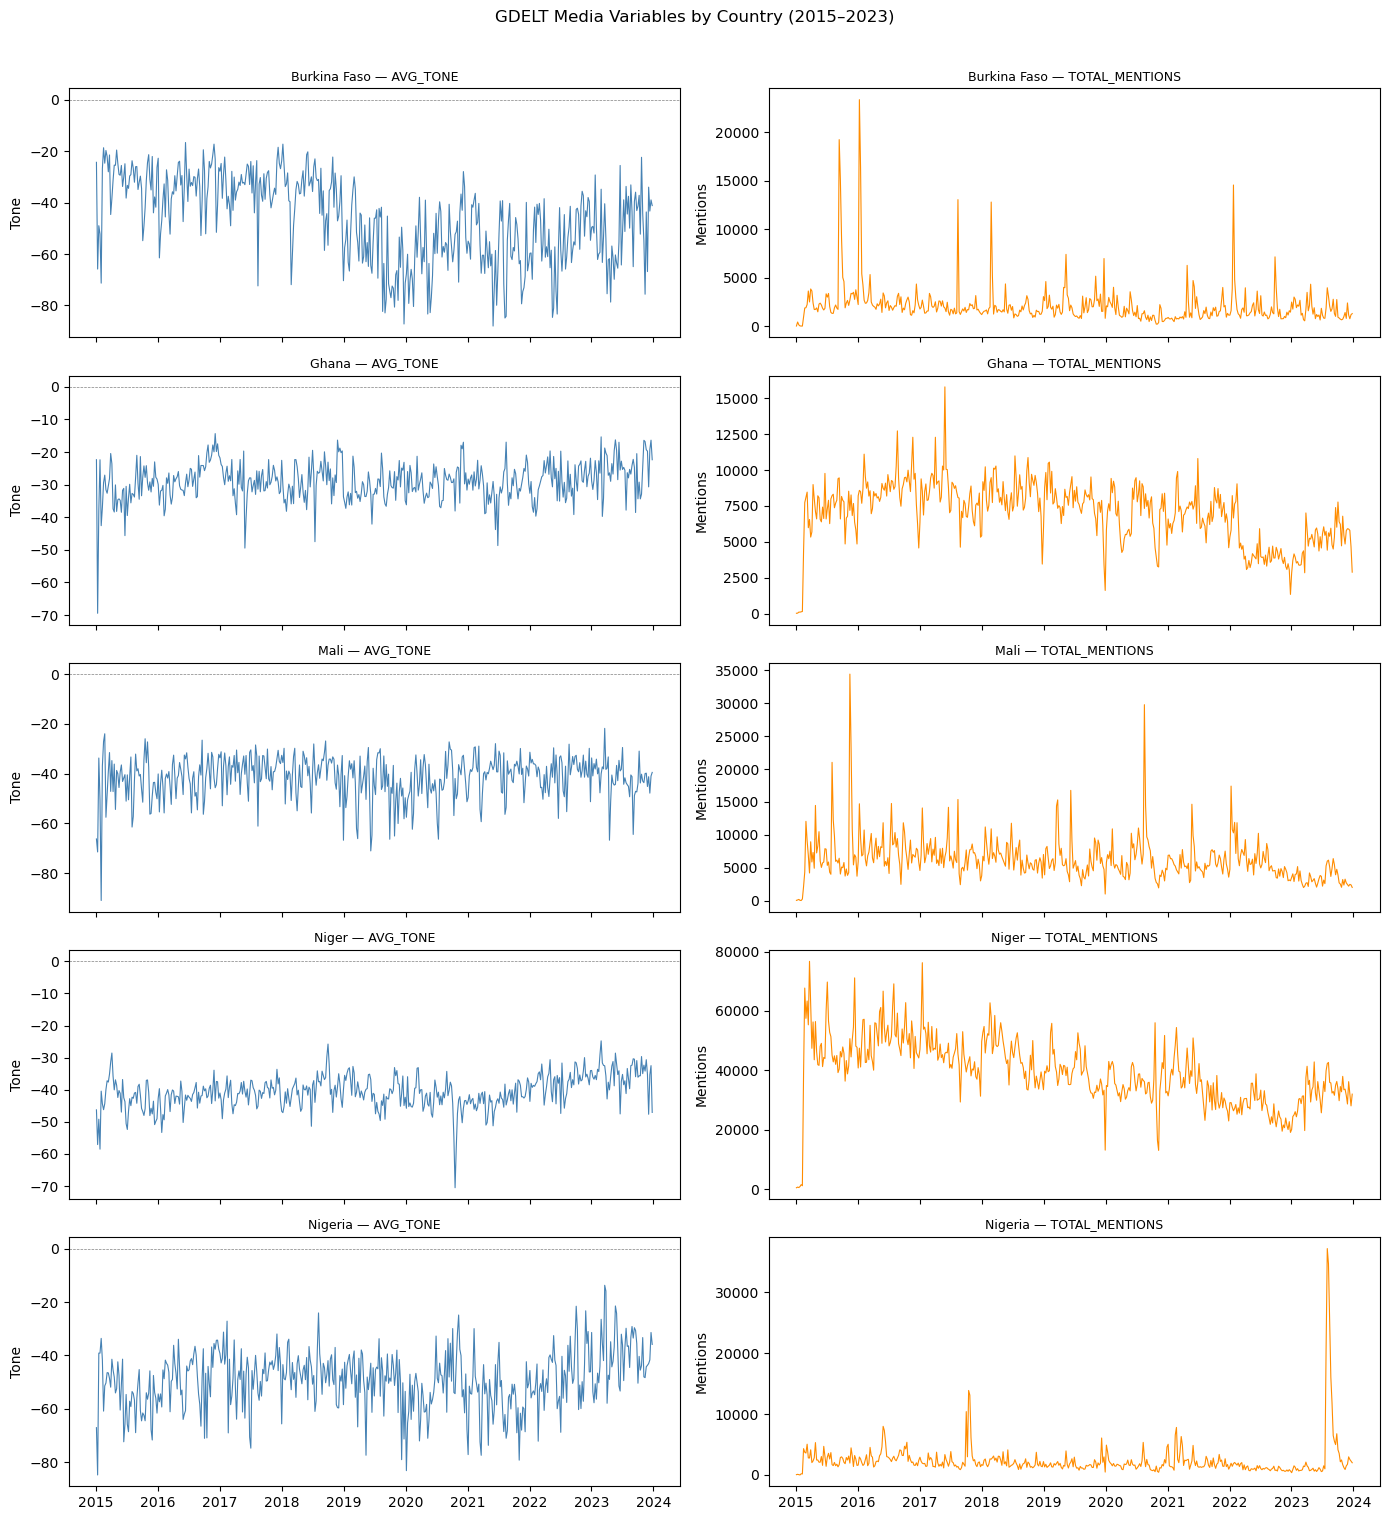

In [14]:
fig, axes = plt.subplots(len(TARGET_COUNTRIES), 2,
                          figsize=(14, 3 * len(TARGET_COUNTRIES)), sharex=True)

for i, country in enumerate(sorted(TARGET_COUNTRIES)):
    sub = gdelt_panel[gdelt_panel["COUNTRY"] == country]
    axes[i, 0].plot(sub["week_start"], sub["avg_tone"], lw=0.8, color="steelblue")
    axes[i, 0].axhline(0, color="gray", lw=0.5, ls="--")
    axes[i, 0].set_title(f"{country} — AVG_TONE", fontsize=9)
    axes[i, 0].set_ylabel("Tone")
    axes[i, 1].plot(sub["week_start"], sub["total_mentions"], lw=0.8, color="darkorange")
    axes[i, 1].set_title(f"{country} — TOTAL_MENTIONS", fontsize=9)
    axes[i, 1].set_ylabel("Mentions")

plt.suptitle("GDELT Media Variables by Country (2015–2023)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PROC_DIR / "gdelt_media_timeline.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Export

In [15]:
OUT_PATH = PROC_DIR / "gdelt_country_week_processed.csv"
gdelt_panel.to_csv(OUT_PATH, index=False)
print(f"Saved → {OUT_PATH}")
print(f"Shape: {gdelt_panel.shape}")
print(f"Columns: {gdelt_panel.columns.tolist()}")

Saved → C:\Users\faiza\Documents\Uni\Year 3\Thesis\Data Preprocessing\processed\gdelt_country_week_processed.csv
Shape: (2345, 10)
Columns: ['COUNTRY', 'week_start', 'n_events_gdelt', 'total_mentions', 'total_articles', 'avg_tone', 'avg_goldstein', 'tone_lag1', 'goldstein_lag1', 'mentions_lag1']
